## Import some packages

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import integrate
import sys
import os
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "ADFWI").exists():
    REPO_ROOT = Path("/liufeng1afs/project/04_Inversion/ADFWI-github")
os.chdir(REPO_ROOT)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import ADFWI
from ADFWI.propagator  import *
from ADFWI.model       import *
from ADFWI.view        import *
from ADFWI.utils       import *
from ADFWI.survey      import *

project_path = os.path.join("examples", "validation", "marmousi2_acoustic_bv12", "outputs", "minimal_notebook")
for subdir in ["model", "waveform", "survey"]:
    os.makedirs(os.path.join(project_path, subdir), exist_ok=True)


/liufeng1afs/software/miniconda3/envs/adfwi/lib/python3.9/site-packages/torch_npu/utils/collect_env.py:58: UserWarning: Warning: The /usr/local/Ascend/ascend-toolkit/latest owner does not match the current owner.
  warnings.warn(f"Warning: The {path} owner does not match the current owner.")
/liufeng1afs/software/miniconda3/envs/adfwi/lib/python3.9/site-packages/torch_npu/utils/collect_env.py:58: UserWarning: Warning: The /usr/local/Ascend/ascend-toolkit/8.2.RC2/aarch64-linux/ascend_toolkit_install.info owner does not match the current owner.
  warnings.warn(f"Warning: The {path} owner does not match the current owner.")
/liufeng1afs/software/miniconda3/envs/adfwi/lib/python3.9/site-packages/torch_npu/utils/collect_env.py:58: UserWarning: Warning: The /usr/local/Ascend/ascend-toolkit/latest owner does not match the current owner.
  warnings.warn(f"Warning: The {path} owner does not match the current owner.")
/liufeng1afs/software/miniconda3/envs/adfwi/lib/python3.9/site-packages/torch_

## Basic Parameter

In [2]:
device = "npu:0"          # Validation device
backend = ADFWI.set_backend(device, dtype="float32")
dtype = torch.float32     # Set data type to 32-bit floating point
ox, oz = 0, 0             # Origin coordinates for x and z directions
nz, nx = 88, 200          # Grid dimensions in z and x directions
dx, dz = 40, 40           # Grid spacing in x and z directions
nt, dt = 3000, 0.003      # Time steps and time interval
nabc = 30                 # Thickness of the absorbing boundary layer
f0 = 5                    # Initial frequency in Hz
free_surface = True       # Enable free surface boundary condition

validation_shots = 3      # Keep validation small; increase to 40 to match the full example
checkpoint_segments = 1   # NPU memory is sufficient for the current reduced validation


## Define the True Velocity Model

In [3]:
# Load the Marmousi model dataset
marmousi_model = load_marmousi_model(in_dir="./examples/datasets/marmousi2_source")

# Resample the Marmousi model for the defined coordinates
x = np.linspace(5000, 5000 + dx * nx, nx)
z = np.linspace(0, dz * nz, nz)
vel_model = resample_marmousi_model(x, z, marmousi_model)

# Extract and transpose the primary wave velocity (vp)
vp = vel_model["vp"].T

# Calculate density (rho) based on velocity
rho = np.power(vp, 0.25) * 310

# Initialize the AcousticModel with parameters and properties
model = AcousticModel(ox, oz, nx, nz, dx, dz,
                      vp, rho,
                      vp_grad=False,
                      free_surface=free_surface,
                      abc_type="PML",
                      abc_jerjan_alpha=0.007,
                      nabc=nabc,
                      device=device,
                      dtype=dtype)

# Save the model to a file
model.save(os.path.join(project_path, "model/true_model.npz"))

# Print the model representation
print(model.__repr__())


model with parameters ['vp', 'rho']:
  Model vp  :  1500.00 -  4777.70 m/s   , requires_grad = False, constrain bound: None - None
  Model rho :  1929.23 -  2577.31 kg/m^3, requires_grad = False, constrain bound: None - None
  Model orig: ox =   0.00, oz =   0.00 m
  Model grid: dx =  40.00, dz =  40.00 m
  Model dims: nx =    200, nz =     88
  Model size: 35200
  Free surface: True
  Absorbing layers: 30



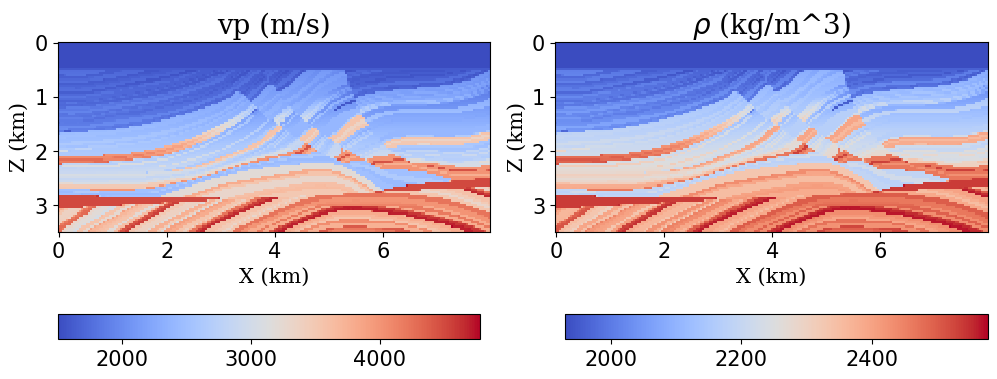

In [4]:
# Plot the primary wave velocity (vp) and density (rho) of the model
model._plot_vp_rho(figsize=(12, 5), wspace=0.15, cbar_pad_fraction=0.02,
                   cmap="coolwarm", save_path=os.path.join(project_path, "model/true_vp_rho.png"))


## Define the observed System: Survey = Source + Receiver

In [5]:
# Define source positions in the model
src_z = np.array([1 for i in range(2, nx - 1, 5)])[:validation_shots]
src_x = np.array([i for i in range(2, nx - 1, 5)])[:validation_shots]

# Generate wavelet for the source
src_t, src_v = wavelet(nt, dt, f0, amp0=1)
try:
    src_v = integrate.cumtrapz(src_v, axis=-1, initial=0)
except AttributeError:
    src_v = integrate.cumulative_trapezoid(src_v, axis=-1, initial=0)

source = Source(nt=nt, dt=dt, f0=f0)

# Add each source position individually, matching the original Marmousi2 example style
for i in range(len(src_x)):
    source.add_source(src_x=src_x[i], src_z=src_z[i], src_wavelet=src_v,
                      src_type="mt", src_mt=np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]]))


In [6]:
# Define receiver positions in the model
rcv_z = np.array([1 for i in range(0, nx, 1)])
rcv_x = np.array([j for j in range(0, nx, 1)])

receiver = Receiver(nt=nt, dt=dt)

# Add each receiver individually, matching the original Marmousi2 example style
for i in range(len(rcv_x)):
    receiver.add_receiver(rcv_x=rcv_x[i], rcv_z=rcv_z[i], rcv_type="pr")


In [7]:
# Create a survey object using the defined source and receiver
survey = Survey(source=source, receiver=receiver)

# Print a representation of the survey object to check its configuration
print(survey.__repr__())


Survey Information:
Seismic Source:
  Source wavelet: 3000 samples at 3.00 ms
  Source number : 3
  Source types  : ['mt']
  Source x range: 2 - 12 (grids)
  Source z range: 1 - 1 (grids)

Seismic Receiver:
  Receiver data   : 3000 samples at 3.00 ms
  Receiver number : 200
  Receiver types  : ['pr']
  Receiver x range: 0 - 199 (grids)
  Receiver z range: 1 - 1 (grids)



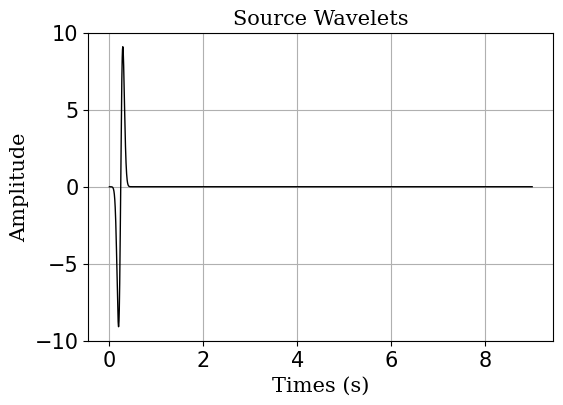

In [8]:
# Plot the wavelet used in the source
source.plot_wavelet(save_path=os.path.join(project_path, "survey/wavelets.png"))


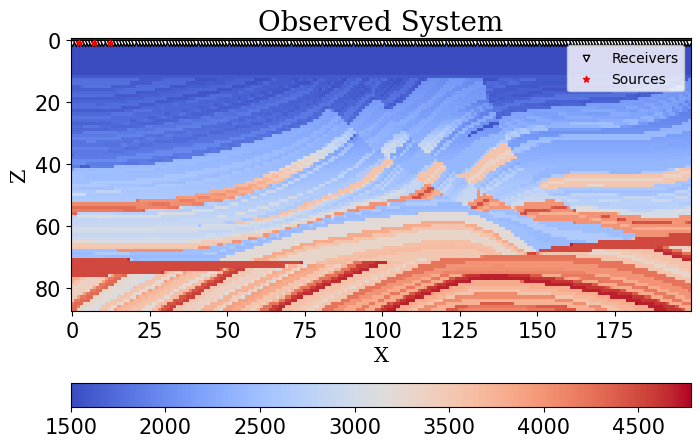

In [9]:
# Plot the survey configuration over the velocity model
survey.plot(model.vp, cmap="coolwarm", save_path=os.path.join(project_path, "survey/observed_system.png"))


## Define the propagator & Forward Modeling

In [10]:
# Initialize the wave propagator using the specified model and survey configuration
F = AcousticPropagator(model, survey, device=device)


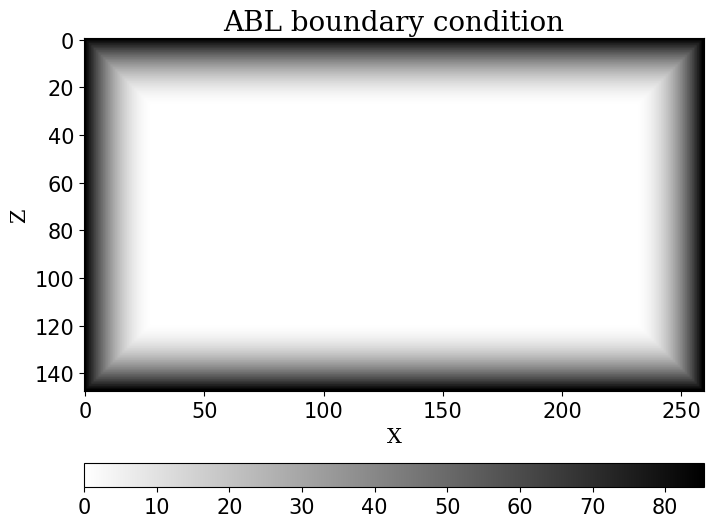

In [11]:
# Retrieve the damping array from the propagator and plot it to visualize boundary conditions
damp = F.damp
plot_damp(damp, save_path=os.path.join(project_path, "model/boundary_condition.png"))


In [12]:
# Perform the forward propagation to record waveforms
record_waveform = F.forward(checkpoint_segments=checkpoint_segments)

# Extract recorded pressure wavefield and particle velocities
rcv_p = record_waveform["p"]
rcv_u = record_waveform["u"]
rcv_w = record_waveform["w"]


In [13]:
# Create a SeismicData object to store observed data from the survey
d_obs = SeismicData(survey)

# Record the waveform data into the SeismicData object
d_obs.record_data(record_waveform)

# Save the recorded data to a specified file
d_obs.save(os.path.join(project_path, "waveform/obs_data.npz"))


## Visualization the Synthetic Waveform

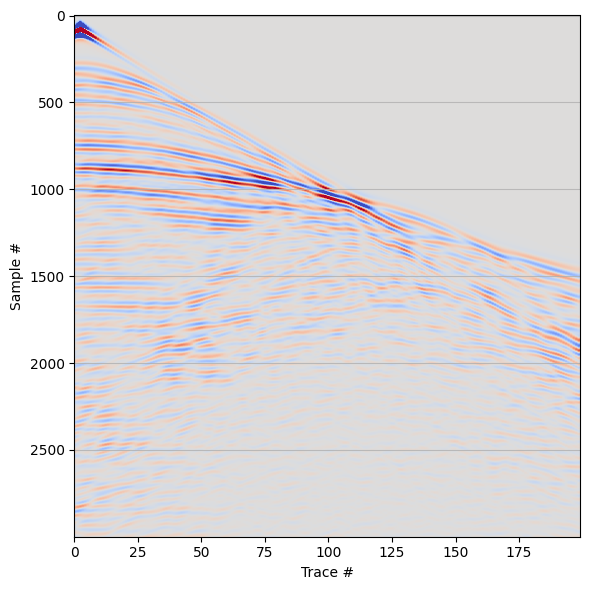

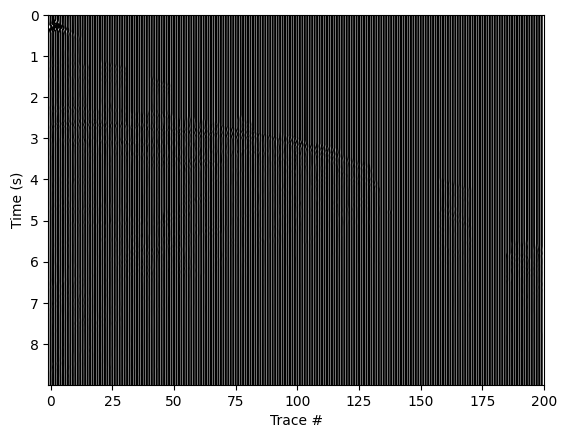

In [14]:
normalize = False

# Plot the first shot, matching the visualization style of the original example
d_obs.plot_waveform2D(
    i_shot=0,
    rcv_type="pressure",
    acoustic_or_elastic="acoustic",
    normalize=normalize,
    figsize=(6, 6),
    cmap="coolwarm",
    save_path=os.path.join(project_path, "waveform/obs_2D_shot_0.png"),
    show=True,
)

d_obs.plot_waveform_wiggle(
    i_shot=0,
    rcv_type="pressure",
    acoustic_or_elastic="acoustic",
    normalize=normalize,
    save_path=os.path.join(project_path, "waveform/obs_wiggle_shot_0.png"),
    show=True,
)


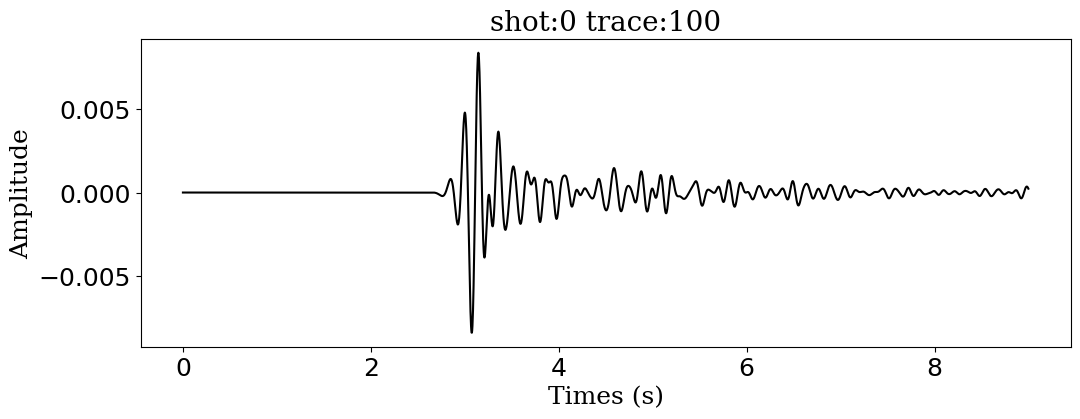

In [15]:
# Plot the waveform trace for a specific shot and trace index
d_obs.plot_waveform_trace(
    i_shot=0,
    i_trace=100,
    rcv_type="pressure",
    acoustic_or_elastic="acoustic",
    normalize=False,
    save_path=os.path.join(project_path, "waveform/obs_trace_shot_0_trace_100.png"),
    show=True,
)
